# Módulo 7 · Clase 3 — Titanic de punta a punta

**Machine Learning for Petroleum Engineers Using Python** · SLB Ecuador / UDLA

---

### La pregunta

Los 891 pasajeros del Titanic — el naufragio mejor documentado de la
historia. Dos preguntas, puramente técnicas:

1. **¿Qué separó a quienes sobrevivieron de quienes no?**
2. Para un perfil dado, **¿cuál es su probabilidad?** — no un «sí o no»:
   un número entre 0 y 1.

### Por qué esta demo importa para SU proyecto

Este cuaderno es **el flujo profesional completo**, y es el estándar de lo
que su proyecto entrega el jueves:

| paso | acá se ve |
|---|---|
| EDA completo | § 1 |
| Limpieza, con decisiones escritas | § 2 |
| **Comparación de modelos** (GridSearch) | § 3 |
| Resultado honesto, en probabilidades | § 4 |
| **Explicabilidad** — global y por predicción | § 5 |
| La herramienta (Gradio, con explicación) | § 6 |

Cada sección lleva **el prompt que se usó** con el agente. El código de
abajo es lo que salió — revisado, que es la parte que no se delega.

## 0 · Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix

DATOS = "https://raw.githubusercontent.com/cmosquerat/slb-diplomado/main/datos/"
SEMILLA = 0

try:
    import google.colab              # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

print("listo. ¿en Colab?", EN_COLAB)

listo. ¿en Colab? False


---

# § 1 · EDA — mirar antes de modelar

El prompt:

```
Tengo el DataFrame `pasajeros`: los 891 pasajeros del Titanic. Columnas:
survived (0/1), pclass (1ª/2ª/3ª), sex, age, sibsp (hermanos/cónyuge a
bordo), parch (padres/hijos a bordo), fare (tarifa), embarked (puerto),
y varias más.

OBJETIVO: un EDA para entender qué separa a quienes sobrevivieron.

- estructura y faltantes de cada columna
- tasa de supervivencia global, por sexo y por clase
- distribución de edades y tarifas
- gráficas que se entiendan solas, en español

CRITERIO: al final, dime en una lista qué columnas te parecen
sospechosas o redundantes ANTES de modelar.
```

In [2]:
pasajeros = pd.read_csv(DATOS + "pasajeros_titanic.csv")
print(f"{len(pasajeros)} pasajeros, {pasajeros.shape[1]} columnas")
pasajeros.head(3)

891 pasajeros, 15 columnas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


In [3]:
# faltantes: lo primero que se mira
faltan = pasajeros.isna().sum()
print("columnas con faltantes:")
print(faltan[faltan > 0].to_string())
print(f"\ntasa de supervivencia global: {100*pasajeros.survived.mean():.1f} %")

columnas con faltantes:
age            177
embarked         2
deck           688
embark_town      2

tasa de supervivencia global: 38.4 %


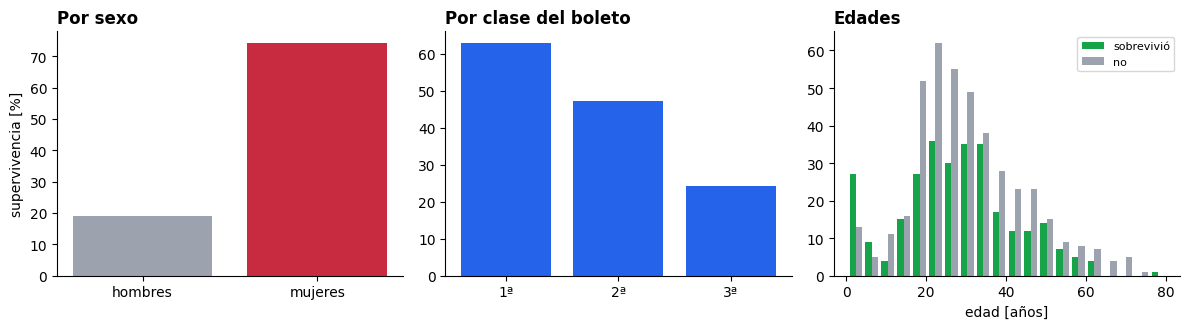

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

por_sexo = pasajeros.groupby("sex").survived.mean() * 100
axes[0].bar(["hombres", "mujeres"],
            [por_sexo["male"], por_sexo["female"]],
            color=["#9CA3AF", "#C82B40"])
axes[0].set_ylabel("supervivencia [%]")
axes[0].set_title("Por sexo", loc="left", fontweight="bold")

por_clase = pasajeros.groupby("pclass").survived.mean() * 100
axes[1].bar(["1ª", "2ª", "3ª"], por_clase.values, color="#2563EB")
axes[1].set_title("Por clase del boleto", loc="left", fontweight="bold")

axes[2].hist([pasajeros[pasajeros.survived == 1].age.dropna(),
              pasajeros[pasajeros.survived == 0].age.dropna()],
             bins=20, label=["sobrevivió", "no"],
             color=["#16A34A", "#9CA3AF"])
axes[2].set_xlabel("edad [años]")
axes[2].legend(fontsize=8)
axes[2].set_title("Edades", loc="left", fontweight="bold")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Tres hechos saltan solos: el **sexo** separa brutalmente (los botes fueron
«mujeres y niños primero»), la **clase del boleto** escalona la
supervivencia, y entre los niños se sobrevivió más.

Y el criterio del prompt pagó: el agente listó **columnas sospechosas**.
Vamos a verlas — porque una de ellas es una trampa mortal.

---

# § 2 · Limpieza — y la trampa de la fuga

Miren la columna `alive`:

In [5]:
print(pasajeros[["survived", "alive"]].head(6).to_string(index=False))
print("\n¿'alive' dice EXACTAMENTE lo mismo que 'survived'?:",
      (pasajeros.alive.map({"yes": 1, "no": 0}) == pasajeros.survived).all())

 survived alive
        0    no
        1   yes
        1   yes
        1   yes
        0    no
        0    no

¿'alive' dice EXACTAMENTE lo mismo que 'survived'?: True


`alive` es **la respuesta, disfrazada de columna**. Si se la damos al
modelo, «predice» perfecto — miren:

In [6]:
# el "modelo perfecto": tres lineas, accuracy 100 %
X_trampa = pd.get_dummies(pasajeros[["alive"]])
Xe, Xx, ye, yx = train_test_split(X_trampa, pasajeros.survived,
                                  test_size=0.2, random_state=SEMILLA)
tramposo = RandomForestClassifier(50, random_state=SEMILLA).fit(Xe, ye)
print(f"accuracy del 'modelo perfecto': "
      f"{accuracy_score(yx, tramposo.predict(Xx)):.3f}")

accuracy del 'modelo perfecto': 1.000


**1.000.** Y no sirve para absolutamente nada: para saber `alive` hay que
saber ya si sobrevivió. Esto se llama **fuga de información** (*leakage*),
y es el error más caro del ML en producción — el modelo brilla en el
cuaderno y muere en el mundo real, donde la respuesta no viene incluida.

> **La regla: si un modelo acierta casi todo, no celebren — desconfíen.**

Decisiones de limpieza, escritas:

In [7]:
# 1) FUERA las columnas que repiten al objetivo o derivan de otras:
#    alive       = survived disfrazado (la fuga)
#    class       = pclass en texto
#    embark_town = embarked en largo
#    who, adult_male, alone = derivadas de sex/age/sibsp/parch
# 2) FUERA deck: 688 de 891 faltantes (77 %) -- no hay con que rellenar eso
# 3) age: 177 faltantes -> mediana (y se dice)
# 4) embarked: 2 faltantes -> el puerto mas comun

t = pasajeros[["survived", "pclass", "sex", "age",
               "sibsp", "parch", "fare", "embarked"]].copy()
t["age"] = t.age.fillna(t.age.median())
t["embarked"] = t.embarked.fillna(t.embarked.mode()[0])

print(f"columnas finales: {list(t.columns)}")
print(f"faltantes restantes: {int(t.isna().sum().sum())}")

columnas finales: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
faltantes restantes: 0


---

# § 3 · Comparación de modelos — GridSearch

Hasta ahora siempre usamos *un* modelo con *una* receta. El flujo
profesional prueba **varios modelos con varias recetas** y deja que la
validación cruzada decida. Eso es `GridSearchCV`:

- **Grid** — la parrilla de recetas (combinaciones de hiperparámetros)
- **Search** — las prueba todas
- **CV** — *cross-validation*: cada receta se examina 5 veces con 5
  particiones distintas del entrenamiento, y se promedia. Así una
  partición con suerte no elige a la receta equivocada.

El prompt:

```
Con el DataFrame `t` limpio (891 filas):

OBJETIVO: comparar tres modelos para predecir survived, con búsqueda de
hiperparámetros, y elegir el mejor con honestidad.

RESTRICCIONES:
- candidatos: LogisticRegression (con StandardScaler en Pipeline),
  RandomForestClassifier y HistGradientBoostingClassifier
- GridSearchCV con cv=5 y accuracy, random_state=0 en todo
- reserva ANTES un 20% de examen final, estratificado, que ninguna
  búsqueda puede tocar
- categóricas con get_dummies

CRITERIO DE ACEPTACIÓN:
- una tabla: modelo, mejor receta, accuracy de validación cruzada
- el examen final se corre UNA sola vez, con el ganador
```

In [8]:
X = pd.get_dummies(t.drop(columns="survived"), columns=["sex", "embarked"])
y = t.survived
columnas = list(X.columns)

# el examen final se aparta ANTES de cualquier busqueda
X_ent, X_exa, y_ent, y_exa = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA, stratify=y)
print(f"para buscar y validar: {len(X_ent)} | examen final: {len(X_exa)}")

para buscar y validar: 712 | examen final: 179


In [9]:
CANDIDATOS = {
    "Regresión logística": (
        Pipeline([("esc", StandardScaler()),
                  ("m", LogisticRegression(max_iter=3000,
                                           random_state=SEMILLA))]),
        {"m__C": [0.1, 1, 10]}),
    "Bosque aleatorio": (
        RandomForestClassifier(300, random_state=SEMILLA, n_jobs=-1),
        {"max_depth": [4, 7, None], "min_samples_leaf": [1, 4]}),
    "Gradient boosting": (
        HistGradientBoostingClassifier(random_state=SEMILLA),
        {"learning_rate": [0.05, 0.1], "max_leaf_nodes": [15, 31]}),
}

resultados = {}
for nombre, (modelo, grid) in CANDIDATOS.items():
    busqueda = GridSearchCV(modelo, grid, cv=5, scoring="accuracy",
                            n_jobs=-1).fit(X_ent, y_ent)
    resultados[nombre] = busqueda
    print(f"{nombre:22s} CV {busqueda.best_score_:.3f}   "
          f"{busqueda.best_params_}")

mejor_nombre = max(resultados, key=lambda k: resultados[k].best_score_)
modelo = resultados[mejor_nombre].best_estimator_
print(f"\nGANADOR: {mejor_nombre}")

/private/tmp/claude-501/-Users-cmosquerat-Documents-GitHub-slb-diplomado/17ff0dd6-d936-43c0-bd10-f0fc4e571d53/scratchpad/v7/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/private/tmp/claude-501/-Users-cmosquerat-Documents-GitHub-slb-diplomado/17ff0dd6-d936-43c0-bd10-f0fc4e571d53/scratchpad/v7/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/private/tmp/claude-501/-Users-cmosquerat-Documents-GitHub-slb-diplomado/17ff0dd6-d936-43c0-bd10-f0fc4e571d53/scratchpad/v7/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/private/tmp/claude-501/-Users-cmosquerat-Documents-GitHub-slb-diplomado/17ff0dd6-d936-43c0-bd10-f0fc4e571d53/scratchpad/v7/lib/python3.9

Regresión logística    CV 0.801   {'m__C': 1}


Bosque aleatorio       CV 0.826   {'max_depth': 7, 'min_samples_leaf': 1}


Gradient boosting      CV 0.833   {'learning_rate': 0.05, 'max_leaf_nodes': 31}

GANADOR: Gradient boosting


Los tres quedan en un pañuelo — **0.80 a 0.83** — y gana el *gradient
boosting* (árboles que se corrigen en cadena: cada uno aprende de los
errores del anterior; primo del bosque, que vota en paralelo).

Nótese lo que **no** pasó: nadie sacó 0.99. Después de ver la fuga, un
número así nos habría hecho parar en seco.

---

# § 4 · El resultado — desde las probabilidades

El examen final, **una sola vez**, con datos que ninguna búsqueda tocó:

examen final: 0.816  (146 de 179)


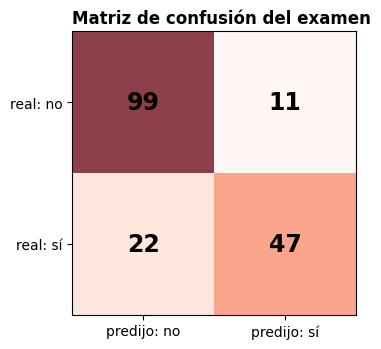

In [10]:
acierto = accuracy_score(y_exa, modelo.predict(X_exa))
print(f"examen final: {acierto:.3f}  "
      f"({(y_exa == modelo.predict(X_exa)).sum()} de {len(y_exa)})")

mc = confusion_matrix(y_exa, modelo.predict(X_exa))
fig, ax = plt.subplots(figsize=(4.6, 3.6))
ax.imshow(mc, cmap="Reds", alpha=.75)
for i in range(2):
    for j in range(2):
        ax.text(j, i, mc[i, j], ha="center", va="center",
                fontsize=17, fontweight="bold")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["predijo: no", "predijo: sí"])
ax.set_yticklabels(["real: no", "real: sí"])
ax.set_title("Matriz de confusión del examen", loc="left", fontweight="bold")
plt.tight_layout(); plt.show()

Pero el modelo no dice «sí o no»: dice **0.07** o **0.91**. Esa es la
salida honesta — y la única útil. Veamos si esas probabilidades **valen
algo**:

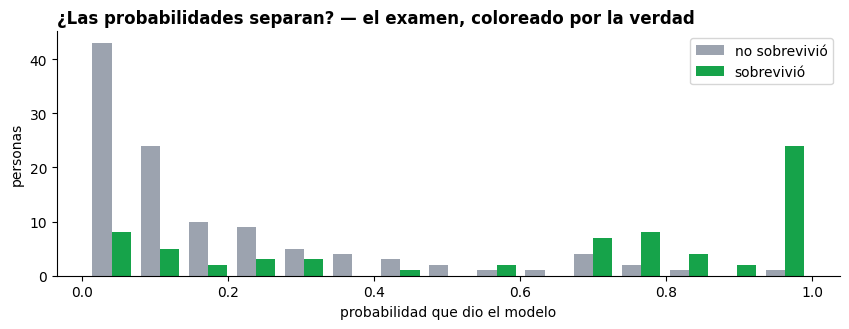

a 32 personas les dio más de 80 %: sobrevivieron 30 (94 %)


In [11]:
proba = modelo.predict_proba(X_exa)[:, 1]

fig, ax = plt.subplots(figsize=(8.6, 3.4))
ax.hist([proba[y_exa == 0], proba[y_exa == 1]], bins=15,
        label=["no sobrevivió", "sobrevivió"], color=["#9CA3AF", "#16A34A"])
ax.set_xlabel("probabilidad que dio el modelo")
ax.set_ylabel("personas")
ax.legend()
ax.set_title("¿Las probabilidades separan? — el examen, coloreado por la verdad",
             loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

alta = proba > 0.8
print(f"a {alta.sum()} personas les dio más de 80 %: "
      f"sobrevivieron {int(y_exa[alta].sum())} "
      f"({100*y_exa[alta].mean():.0f} %)")

---

# § 5 · Explicabilidad — el porqué de cada número

Un 0.91 sin explicación no se puede defender en una reunión. **SHAP**
responde la pregunta que sigue siempre al número: *¿por qué?*

**La idea, sin matemática:** a cada variable se le asigna la parte justa
del empujón que dio — cuánto movió la predicción hacia arriba o hacia
abajo respecto del pasajero promedio. Viene de la teoría de juegos
(valores de Shapley: cómo repartir el premio de un equipo entre sus
jugadores según lo que aportó cada uno).

El prompt:

```
Con el modelo ganador y el examen X_exa:

OBJETIVO: explicabilidad con SHAP.
- global: qué variables mandan y en qué dirección (summary plot)
- individual: para un pasajero del examen, sus factores con magnitud
  y signo, en español

CRITERIO: que yo pueda leer el gráfico global en una frase por variable.
```

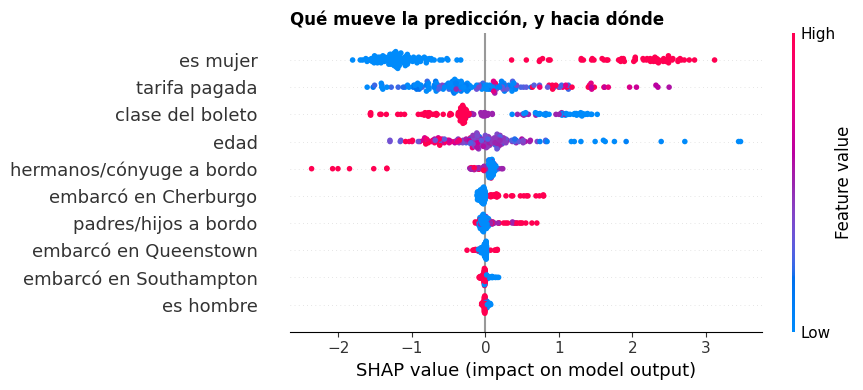

In [12]:
try:
    import shap
except ImportError:
    %pip install -q shap
    import shap

NOMBRES_ES = {"pclass": "clase del boleto", "age": "edad",
              "sibsp": "hermanos/cónyuge a bordo",
              "parch": "padres/hijos a bordo", "fare": "tarifa pagada",
              "sex_female": "es mujer", "sex_male": "es hombre",
              "embarked_C": "embarcó en Cherburgo",
              "embarked_Q": "embarcó en Queenstown",
              "embarked_S": "embarcó en Southampton"}

X_exa_es = X_exa.rename(columns=NOMBRES_ES)

explicador = shap.TreeExplainer(modelo)
valores = explicador.shap_values(X_exa)

shap.summary_plot(valores, X_exa_es, show=False, plot_size=(9, 4))
plt.title("Qué mueve la predicción, y hacia dónde", loc="left",
          fontweight="bold")
plt.tight_layout(); plt.show()

**Cómo se lee:** cada punto es un pasajero; derecha = empuja hacia
*sobrevivir*, izquierda = hacia *no*. El color es el valor de la variable
(rojo alto, azul bajo).

- **Ser mujer / ser hombre** parte el gráfico en dos: es el factor
  dominante, con diferencia.
- **Clase del boleto**: alta (3ª, rojo) empuja a la izquierda — tercera
  clase restaba.
- **Edad**: baja (azul) empuja a la derecha — los niños primero.
- **Tarifa**: alta empuja a sobrevivir — es la clase, contada en dinero.

El modelo redescubrió, solo, el protocolo de evacuación de 1912. Y ahora
lo mismo, para **una** persona:

pasajero 3 del examen: clase 3, edad 28, tarifa 10
probabilidad de sobrevivir: 0.21   (real: no sobrevivió)



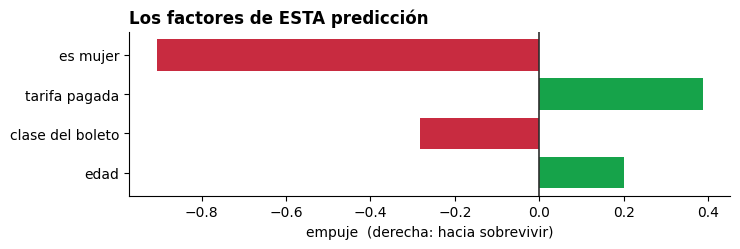

In [13]:
def explicar_persona(i):
    '''La prediccion de un pasajero del examen, con sus porques.'''
    fila = X_exa.iloc[[i]]
    p = modelo.predict_proba(fila)[0, 1]
    contrib = pd.Series(explicador.shap_values(fila)[0],
                        index=columnas).sort_values(key=abs, ascending=False)

    print(f"pasajero {i} del examen: clase {int(fila.pclass.iloc[0])}, "
          f"edad {fila.age.iloc[0]:.0f}, tarifa {fila.fare.iloc[0]:.0f}")
    print(f"probabilidad de sobrevivir: {p:.2f}   "
          f"(real: {'sobrevivió' if y_exa.iloc[i] else 'no sobrevivió'})\n")

    top = contrib.head(4)
    fig, ax = plt.subplots(figsize=(7.5, 2.6))
    colores = ["#16A34A" if v > 0 else "#C82B40" for v in top.values[::-1]]
    ax.barh([NOMBRES_ES.get(k, k) for k in top.index[::-1]],
            top.values[::-1], color=colores)
    ax.axvline(0, color="#2D2D2D", lw=1.2)
    ax.set_xlabel("empuje  (derecha: hacia sobrevivir)")
    ax.set_title("Los factores de ESTA predicción", loc="left",
                 fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()


explicar_persona(3)

---

# § 6 · La herramienta — con explicación incluida

La app junta todo: el perfil entra, y salen **la probabilidad** y **sus
porqués** — porque un número sin explicación no se puede defender, ni en
1912 ni en una reunión de operaciones.

El prompt:

```
CONTEXTO: tengo `modelo` (el ganador del GridSearch), `explicador`
(shap.TreeExplainer), `columnas` (el orden del entrenamiento) y el
DataFrame limpio `t`.

OBJETIVO: app de Gradio — perfil del pasajero (clase, sexo, edad,
hermanos/cónyuge, padres/hijos, tarifa, puerto) y devuelve:
1. "X de cada 100 personas con este perfil sobrevivieron"
2. una gráfica con los 4 factores que más empujaron ESTA predicción

RESTRICCIONES:
- controles en español; rangos de edad y tarifa DESDE el dato `t`
- la fila para el modelo se arma como TABLA con las columnas en el
  orden de `columnas` (nunca números pelados)
- launch(share=True)

CRITERIO: una edad fuera del rango del dato se rechaza con mensaje.
```

65 de cada 100 personas con este perfil sobrevivieron.


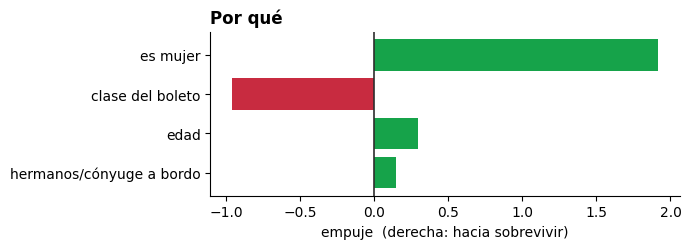

NO SE PUEDE CALCULAR: edad 500 fuera del rango del dato (0 a 80 años).


In [14]:
RANGO_EDAD = (float(t.age.min()), float(t.age.max()))
RANGO_TARIFA = (float(t.fare.min()), float(t.fare.max()))
PUERTOS = {"Cherburgo": "C", "Queenstown": "Q", "Southampton": "S"}


def armar_perfil(clase, sexo, edad, hermanos, padres, tarifa, puerto):
    fila = pd.DataFrame(0, index=[0], columns=columnas, dtype=float)
    fila["pclass"] = clase
    fila["age"] = edad
    fila["sibsp"] = hermanos
    fila["parch"] = padres
    fila["fare"] = tarifa
    fila[f"sex_{'female' if sexo == 'mujer' else 'male'}"] = 1.0
    fila[f"embarked_{PUERTOS[puerto]}"] = 1.0
    return fila


def calcular(clase, sexo, edad, hermanos, padres, tarifa, puerto):
    # el contrato de entrada: los rangos salen del dato
    if not (RANGO_EDAD[0] <= edad <= RANGO_EDAD[1]):
        return (f"NO SE PUEDE CALCULAR: edad {edad} fuera del rango del "
                f"dato ({RANGO_EDAD[0]:.0f} a {RANGO_EDAD[1]:.0f} años).",
                None)

    fila = armar_perfil(clase, sexo, edad, hermanos, padres, tarifa, puerto)
    p = modelo.predict_proba(fila)[0, 1]

    contrib = pd.Series(explicador.shap_values(fila)[0],
                        index=columnas).sort_values(key=abs, ascending=False)
    top = contrib.head(4)
    fig, ax = plt.subplots(figsize=(7, 2.6))
    colores = ["#16A34A" if v > 0 else "#C82B40" for v in top.values[::-1]]
    ax.barh([NOMBRES_ES.get(k, k) for k in top.index[::-1]],
            top.values[::-1], color=colores)
    ax.axvline(0, color="#2D2D2D", lw=1.2)
    ax.set_xlabel("empuje  (derecha: hacia sobrevivir)")
    ax.set_title("Por qué", loc="left", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()

    return (f"{100*p:.0f} de cada 100 personas con este perfil "
            f"sobrevivieron.", fig)


# la funcion se prueba sola primero, como siempre
texto, figura = calcular(3, "mujer", 28, 0, 0, 15, "Southampton")
print(texto)
plt.show()
texto, _ = calcular(1, "hombre", 500, 0, 0, 15, "Southampton")
print(texto)

In [15]:
# la app -- en Colab, esta celda publica el link
try:
    import gradio as gr

    app = gr.Interface(
        fn=calcular,
        inputs=[
            gr.Radio([1, 2, 3], value=3, label="Clase del boleto"),
            gr.Radio(["mujer", "hombre"], value="mujer", label="Sexo"),
            gr.Slider(0, 80, value=28, step=1, label="Edad [años]"),
            gr.Slider(0, 8, value=0, step=1, label="Hermanos/cónyuge a bordo"),
            gr.Slider(0, 6, value=0, step=1, label="Padres/hijos a bordo"),
            gr.Slider(0, 512, value=15, step=1, label="Tarifa pagada [£]"),
            gr.Radio(list(PUERTOS), value="Southampton",
                     label="Puerto de embarque"),
        ],
        outputs=[gr.Textbox(label="Resultado"),
                 gr.Plot(label="Los factores de esta predicción")],
        title="Titanic · Probabilidad de supervivencia",
        description="El modelo devuelve la probabilidad y sus porqués.")

    if EN_COLAB:
        app.launch(share=True)       # <- aqui aparece el link publico
    else:
        print("interfaz construida; en Colab esta celda abre el link")
except ImportError:
    print("gradio no esta en este entorno; en Colab ya viene listo")

gradio no esta en este entorno; en Colab ya viene listo


---

# Cierre de la demo

## Lo que vimos → lo que decidimos

| Lo que vimos | Lo que decidimos |
|---|---|
| `alive` duplicaba al objetivo → accuracy **1.000** | La regla de la fuga: **lo perfecto huele a trampa** |
| `deck` con 77 % de faltantes | Fuera — no hay con qué rellenar eso |
| Tres modelos en un pañuelo (0.80–0.83) | Que decida la **validación cruzada**, no el gusto |
| El modelo da 0.07 o 0.91, no «sí/no» | Entregar **probabilidades** — y verificar que separan |
| Un número no se puede defender solo | **SHAP**: el porqué global y el de cada predicción |
| La herramienta la usa otro | Contrato de entrada + explicación en la app |

## Para su proyecto

Este cuaderno **es la plantilla**: EDA completo → limpieza con decisiones
escritas → comparación de modelos → resultado honesto → explicabilidad →
herramienta. Cámbienle el dato por el suyo, y esa es la entrega del jueves.

---

*Machine Learning for Petroleum Engineers Using Python* · SLB Ecuador / UDLA
· 2026